## Imports

In [8]:
import boto3
import os
from dotenv import load_dotenv
import pandas as pd
import pyarrow as pr
from pathlib import Path

In [79]:
load_dotenv()
os.getenv('AWS_ACCESS_KEY_ID') is not None

True

## Download data

In [10]:
s3 = boto3.client('s3')
BUCKET = "zrive-ds-data"
PREFIX = "groceries/sampled-datasets/"
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=PREFIX
)

keys = []
for element in response['Contents']:
    keys.append(element['Key'])

print(keys)

local_data_dir = Path('../../data/module2')

for key in keys:
    filename = key.split('/')[-1]
    local_path = local_data_dir/filename

    if local_path.exists():
        print(f'{filename} already exists')
        continue

    print(f'Downloading: {filename}')
    s3.download_file(BUCKET,key,local_path)
        

    

['groceries/sampled-datasets/abandoned_carts.parquet', 'groceries/sampled-datasets/inventory.parquet', 'groceries/sampled-datasets/orders.parquet', 'groceries/sampled-datasets/regulars.parquet', 'groceries/sampled-datasets/users.parquet']
abandoned_carts.parquet already exists
inventory.parquet already exists
orders.parquet already exists
regulars.parquet already exists
users.parquet already exists


## Create dataframes

In [11]:
dfs = {}
DATA_DIR = Path('../../data/module2')
for file in os.listdir(DATA_DIR):
    print(file)

regulars.parquet
users.parquet
orders.parquet
abandoned_carts.parquet
inventory.parquet


In [12]:
dfs = {}
DATA_DIR = Path('../../data/module2')
for file in os.listdir(DATA_DIR):
    if file.endswith('.parquet'):
        name = file.replace('.parquet','')
        path = DATA_DIR/file
        dfs[name] = pd.read_parquet(path)

print(dfs.keys())

dict_keys(['regulars', 'users', 'orders', 'abandoned_carts', 'inventory'])


# GENERATE FINAL DF + QUICK EDA

## Problem addressing

To know which final DF we have to create, we have first to define wich information do we want to extract from the data.
In this case, I will suppose that:
1. This data comes from an ecommerce store
2. The ecommerce is interested in studying how their products are working, seeking for the most effective, so they can maintain them on catalog, and for the least, for further analysis on what is happening with them and taking action, for example, by removing them from the catalog

 For this analysis of product, I find very useful a final DF whose main unit is: (product,order), this way, we can study each in context with the orders, so that we can also be aware not only of its number os sales, but also of the purchase rate, rate of abandonment, and more features like this that I find helpful

## Quick sanity and integrity check of each DF

In [13]:
dfs['regulars'].head()

,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


In [14]:
print(dfs['regulars'].shape)
print(list(dfs['regulars'].columns))
print(dfs['regulars'].dtypes)
print(dfs['regulars'].isna().mean()*100)
dfs['regulars'].duplicated().sum()


(18105, 3)
['user_id', 'variant_id', 'created_at']
user_id               object
variant_id             int64
created_at    datetime64[us]
dtype: object
user_id       0.0
variant_id    0.0
created_at    0.0
dtype: float64


123

In [15]:
dfs['regulars'].sort_values(
    ['user_id', 'variant_id', 'created_at']
).head()

,user_id,variant_id,created_at
28235,004b3e3cb9a9f5b0974ce4179db394057c72e7a82077bf...,33667274997892,2021-12-21 21:48:05
19340,005743eefffa4ce840608c4f47b8c548b134d89be5c390...,34081589887108,2021-06-09 08:40:19
4930,005743eefffa4ce840608c4f47b8c548b134d89be5c390...,34519123951748,2021-06-09 08:40:19
2171,0074992079c1836c6509eec748a973dc97388b4877e770...,33667222896772,2020-05-18 20:35:53
2715,0074992079c1836c6509eec748a973dc97388b4877e770...,33667247014020,2020-05-18 20:35:53


- All data seems to be correct in type
- Shape seems to have reasonable size
- There is no na values
- There is duplactes, but they make sense, as as filtered after, they seem to be modifications of the same user in the same product in relation with marking it as regular ot not.

In [16]:
dfs['users'].head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


In [17]:
print(dfs['users'].shape)
print(list(dfs['users'].columns))
print(dfs['users'].dtypes)
print(dfs['users'].isna().mean()*100)
dfs['users'].duplicated().sum()

(4983, 10)
['user_id', 'user_segment', 'user_nuts1', 'first_ordered_at', 'customer_cohort_month', 'count_people', 'count_adults', 'count_children', 'count_babies', 'count_pets']
user_id                   object
user_segment              object
user_nuts1                object
first_ordered_at          object
customer_cohort_month     object
count_people             float64
count_adults             float64
count_children           float64
count_babies             float64
count_pets               float64
dtype: object
user_id                   0.000000
user_segment              0.000000
user_nuts1                1.023480
first_ordered_at          0.000000
customer_cohort_month     0.000000
count_people             93.477825
count_adults             93.477825
count_children           93.477825
count_babies             93.477825
count_pets               93.477825
dtype: float64


0

- All data seems to be correct in type except first ordered at and cohort month, they are type object and they should be datetime. They will be parsed if used in final DF
- Shape seems to have reasonable size.
- NA values are 93%, NMAR in count_people,count_adults,count_children,count_babies and count_pets what suggest that is a fields usually left blank, adn may be correct to drop those columns.
- There is no duplicates, correct as userid should be unique.



In [18]:
dfs['orders'].head()

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [19]:
print(dfs['orders'].shape)
print(list(dfs['orders'].columns))
print(dfs['orders'].dtypes)
print(dfs['orders'].isna().mean()*100)
print(dfs['orders']['id'].duplicated().sum())

(8773, 6)
['id', 'user_id', 'created_at', 'order_date', 'user_order_seq', 'ordered_items']
id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object
dtype: object
id                0.0
user_id           0.0
created_at        0.0
order_date        0.0
user_order_seq    0.0
ordered_items     0.0
dtype: float64
0


- All data seems to be correct in type 
- Shape seems to have reasonable size.
- NA values are 0% in every columns, so data can be collected for further use without restrictions.
- There is no duplicates, correct as id should be unique.

In [20]:
dfs['abandoned_carts'].head()

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


In [21]:
print(dfs['abandoned_carts'].shape)
print(list(dfs['abandoned_carts'].columns))
print(dfs['abandoned_carts'].dtypes)
print(dfs['abandoned_carts'].isna().mean()*100)
print(dfs['abandoned_carts']['id'].duplicated().sum())
set(dfs['abandoned_carts']['id']).issubset(set(dfs['orders']['id']))

(5457, 4)
['id', 'user_id', 'created_at', 'variant_id']
id                     int64
user_id               object
created_at    datetime64[us]
variant_id            object
dtype: object
id            0.0
user_id       0.0
created_at    0.0
variant_id    0.0
dtype: float64
0


False

- All data seems to be correct in type 
- Shape seems to have reasonable size.
- NA values are 0% in every columns, so data can be collected for further use without restrictions.
- There is no duplicates, correct as id should be unique.
- Take into account that the id columns has the same name has the id columns in orders, one of both should be renamed


In [22]:
33618849693828 in dfs['inventory']['variant_id'].values

False

In [23]:
dfs['inventory'].head()

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


In [24]:
print(dfs['inventory'].shape)
print(list(dfs['inventory'].columns))
print(dfs['inventory'].dtypes)
print(dfs['inventory'].isna().mean()*100)
print(dfs['inventory']['variant_id'].duplicated().sum())

(1733, 6)
['variant_id', 'price', 'compare_at_price', 'vendor', 'product_type', 'tags']
variant_id            int64
price               float64
compare_at_price    float64
vendor               object
product_type         object
tags                 object
dtype: object
variant_id          0.0
price               0.0
compare_at_price    0.0
vendor              0.0
product_type        0.0
tags                0.0
dtype: float64
0


- All data seems to be correct in type
- Shape seems to have reasonable size.
- NA values are 0% in every columns, so data can be collected for further use without restrictions.
- There is no duplicates, correct as variant_id should be unique, because it represents a single product

## Creation of the final DF

We will create the final DF using the following columns from the previous dataframes:
- variant_id
- order_id (id from orders renamed)
- abandoned_cart_id (id from abandoned_carts renamed)
- user_id
- user_segment
- price
- vendor
- product_type
- created_at
- cart_size (lenght of ordered_items or of variant_id)
- is_purchased (will be created regarding the column order id)

Each row will be a product in a buy attempt, this attempt migh finish in an order or in an abandoned_cart, the column with a valid id will determine that. Never both columns should be filled in the same row.

In [25]:
orders_expanded = dfs['orders'].copy()
orders_expanded["cart_size"] = orders_expanded["ordered_items"].apply(len)
orders_expanded = orders_expanded.explode("ordered_items")
orders_expanded = orders_expanded.rename(columns={"ordered_items": "variant_id","id":"order_id"})
orders_expanded['abandoned_cart_id'] = None
orders_expanded['is_purchased'] = True
orders_expanded = orders_expanded[['order_id','user_id','created_at','variant_id','cart_size','abandoned_cart_id','is_purchased']]
orders_expanded['variant_id'].nunique()
orders_expanded.head()
orders_expanded['variant_id'].nunique()


2117

In [26]:
abandoned_expanded = dfs['abandoned_carts'].copy()
abandoned_expanded["cart_size"] = abandoned_expanded["variant_id"].apply(len)
abandoned_expanded = abandoned_expanded.explode("variant_id")
abandoned_expanded = abandoned_expanded.rename(columns={"id":"abandoned_cart_id"})
abandoned_expanded['order_id'] = None
abandoned_expanded['is_purchased'] = False
abandoned_expanded.head()

,abandoned_cart_id,user_id,created_at,variant_id,cart_size,order_id,is_purchased
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826459287684,19,None,False
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457616516,19,None,False
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33667192127620,19,None,False
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826412331140,19,None,False
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826472558724,19,None,False


In [27]:
events_df = pd.concat([orders_expanded,abandoned_expanded],axis=0)
events_df = events_df.reset_index(drop=True)
events_df[
    events_df["order_id"].notna() &
    events_df["abandoned_cart_id"].notna()
]

,order_id,user_id,created_at,variant_id,cart_size,abandoned_cart_id,is_purchased


In [28]:
events_df = events_df.merge(
    dfs['inventory'][['variant_id','price','vendor','product_type']],
    on='variant_id',
    how='left'
)

In [29]:
events_df.head()

,order_id,user_id,created_at,variant_id,cart_size,abandoned_cart_id,is_purchased,price,vendor,product_type
0,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,33618849693828,14,None,True,NaN,NaN,NaN
1,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,33618860179588,14,None,True,NaN,NaN,NaN
2,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,33618874040452,14,None,True,NaN,NaN,NaN
3,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,33618907005060,14,None,True,NaN,NaN,NaN
4,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,33618907005060,14,None,True,NaN,NaN,NaN


In [30]:
events_df[events_df["price"].isna()]["variant_id"].nunique()
percent = (events_df[events_df["price"].isna()]["variant_id"].nunique()/events_df['variant_id'].nunique())*100
print(f'there is {percent} % of variant_ids not reported in df inventory')



there is 30.527289546716002 % of variant_ids not reported in df inventory


In [31]:
events_df = events_df.merge(
    dfs["users"][["user_id", "user_segment"]],
    on="user_id",
    how="left"
)

In [32]:
percent_user=events_df[events_df['user_segment'].isna()]['user_id'].nunique()/events_df['user_id'].nunique()
print(f'all users have beed traced')


all users have beed traced


In [33]:
events_df.columns

Index(['order_id', 'user_id', 'created_at', 'variant_id', 'cart_size',
       'abandoned_cart_id', 'is_purchased', 'price', 'vendor', 'product_type',
       'user_segment'],
      dtype='object')

In [34]:
priority_cols = [
    "order_id",
    "abandoned_cart_id",
    "variant_id",
    "user_id",
    "user_segment",
]
other_cols = [c for c in events_df.columns if c not in priority_cols]
events_df = events_df[priority_cols+other_cols]
events_df.head()

,order_id,abandoned_cart_id,variant_id,user_id,user_segment,created_at,cart_size,is_purchased,price,vendor,product_type
0,2204073066628,None,33618849693828,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN
1,2204073066628,None,33618860179588,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN
2,2204073066628,None,33618874040452,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN
3,2204073066628,None,33618907005060,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN
4,2204073066628,None,33618907005060,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN


In [35]:
events_df['price'].isna().mean() *100

12.344860870003673

The final df has been obtained, with the columns explained previously. There have been some problems however, that mus be noted:
- there is a 30.5% of variant_id(products) which hasn't been traced into inventory becuase the variant_id doesn't exit there.
- That is translated into a nan percentage of 12% in the columns of vendor, product_type and price.

## Hypothesis-driven exploration


In this section, wioth the final Data Set already obtained, we will try to explore some hypothesis which can give us more insight information about the business.

The hypothesis that will be tested are:
- Some products are disproportionately represented in abandoned carts compared to complete orders
- products that appear frequently in abandoned carts tend to be less purchased
- products added to cart by users with abandonement behaviour show lower conversion rates

### Hyp 1: Some products are disproportionately represented in abandoned carts compared to complete orders

In [36]:
df = events_df.copy()

In [37]:
df['is_order'] = df['order_id'].notna()
df['is_abandoned'] = df['abandoned_cart_id'].notna()

In [46]:
product_events = df.groupby('variant_id').agg(
    n_orders = ('is_order','sum'),
    n_abandoned = ('is_abandoned','sum')
).reset_index()


product_events['total_events'] = product_events['n_orders'] + product_events['n_abandoned']
product_events['abandonment_ratio'] = product_events['n_abandoned']/product_events['total_events']

product_events.head()

,variant_id,n_orders,n_abandoned,total_events,abandonment_ratio
0,33615294398596,88,18,106,0.169811
1,33618830196868,1,0,1,0.000000
2,33618835243140,1,0,1,0.000000
3,33618835964036,1,0,1,0.000000
4,33618846580868,1,0,1,0.000000


In [47]:
product_events_filtered = product_events[
    product_events["total_events"] >= 10
]
product_events_filtered.head()

,variant_id,n_orders,n_abandoned,total_events,abandonment_ratio
0,33615294398596,88,18,106,0.169811
58,33667166699652,12,0,12,0.000000
63,33667172466820,27,0,27,0.000000
64,33667173449860,17,1,18,0.055556
65,33667174301828,13,2,15,0.133333


In [48]:
product_events_filtered.sort_values(by='abandonment_ratio',
                                    ascending = False
                                   ).head(10)

,variant_id,n_orders,n_abandoned,total_events,abandonment_ratio
1972,39607712219268,0,24,24,1.000000
1870,39539419250820,0,17,17,1.000000
1018,34370916515972,0,32,32,1.000000
1495,39367711916164,0,24,24,1.000000
1459,39336624259204,0,29,29,1.000000
1522,39368665858180,0,10,10,1.000000
1871,39539419447428,0,11,11,1.000000
1458,39336624193668,0,12,12,1.000000
1061,34436055203972,0,21,21,1.000000
2052,39772627304580,4,7,11,0.636364


- The analysis shows that a subset of products concentrates a higher proportion of abandoned carts events relative to competed purchases.
- While this does not imply causality, it suggests that product-level characteristics may be associated with 
higher cart abandonment.

### Hyp2: Porducts that appear frequently on abandoned carts tend to be less purchased

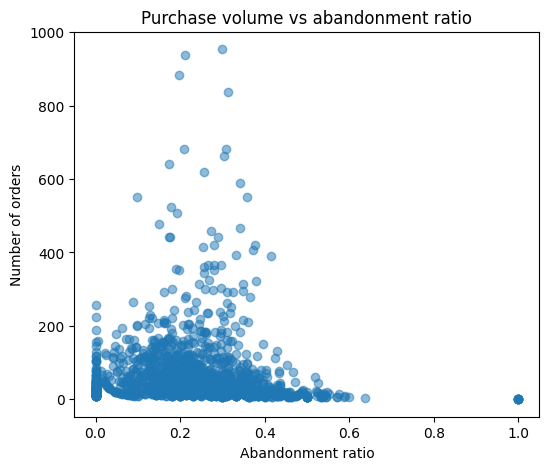

In [50]:
import matplotlib.pyplot as plt

filtered = product_events_filtered[
    product_events_filtered["n_orders"] < 1000
]

plt.figure(figsize=(6, 5))
plt.scatter(
    filtered["abandonment_ratio"],
    filtered["n_orders"],
    alpha=0.5
)
plt.xlabel("Abandonment ratio")
plt.ylabel("Number of orders")
plt.title("Purchase volume vs abandonment ratio")
plt.show()

The figure show that, as expected, the number or orders decreases as the abandonment ratio increases. There are some ouliers in the section 0.2-0.4, these cases may correspond to popular or high-demand products and warrant 
further investigation. Overall, the relationship is descriptive and does not imply causality.

### Hyp3: Products added to the cart by users with abandonment behaviour tend to have lower conversion rates

In [56]:
df = events_df.copy()
df["is_abandoned"] = ~df["is_purchased"]
users_with_abandonment = df[df['is_abandoned']]['user_id'].unique()

In [58]:
df['user_hasEver_abandoned'] = df['user_id'].isin(users_with_abandonment)
df.head()

,order_id,abandoned_cart_id,variant_id,user_id,user_segment,created_at,cart_size,is_purchased,price,vendor,product_type,is_abandoned,user_hasEver_abandoned
0,2204073066628,None,33618849693828,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN,False,True
1,2204073066628,None,33618860179588,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN,False,True
2,2204073066628,None,33618874040452,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN,False,True
3,2204073066628,None,33618907005060,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN,False,True
4,2204073066628,None,33618907005060,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,Proposition,2020-04-30 14:32:19,14,True,NaN,NaN,NaN,False,True


In [67]:
product_user_abandonment = df[df['user_hasEver_abandoned']].groupby('variant_id').agg(
    n_orders = ('is_purchased','sum'),
    n_abandoned = ('is_abandoned','sum')
).reset_index()

product_user_abandonment['conversion_rate'] = product_user_abandonment['n_orders']/(product_user_abandonment['n_orders']+product_user_abandonment['n_abandoned'])
product_user_abandonment.sort_values(
    by = 'n_abandoned',
    ascending = False
).head()

,variant_id,n_orders,n_abandoned,conversion_rate
563,34081589887108,3525,608,0.852891
735,34284951863428,839,478,0.637054
717,34284950356100,817,409,0.666395
611,34137590366340,1182,395,0.749524
711,34284949766276,696,382,0.645640


In [73]:
product_events['conversion_rate_global'] = 1-product_events['abandonment_ratio']
product_events_filtered = product_events[
    product_events["total_events"] >= 10]
product_events.head()

,variant_id,n_orders,n_abandoned,total_events,abandonment_ratio,conversion_rate_global
0,33615294398596,88,18,106,0.169811,0.830189
1,33618830196868,1,0,1,0.000000,1.000000
2,33618835243140,1,0,1,0.000000,1.000000
3,33618835964036,1,0,1,0.000000,1.000000
4,33618846580868,1,0,1,0.000000,1.000000


In [75]:
comparison = product_events.merge(
    product_user_abandonment[['variant_id','conversion_rate']
        ].rename(columns={'conversion_rate':'conversion_rate_abandon_users'}),
    on = 'variant_id',
    how = 'inner'
)

In [76]:
comparison[[
    "conversion_rate_global",
    "conversion_rate_abandon_users"
]].describe()

,conversion_rate_global,conversion_rate_abandon_users
count,2017.000000,2017.000000
mean,0.779827,0.753351
std,0.199878,0.206736
min,0.000000,0.000000
25%,0.675000,0.647929
50%,0.795918,0.750000
75%,0.975610,0.962963
max,1.000000,1.000000


When comparing the same metric of conversion rate accross all users or only in users with abandonment behavious, the analysis shows that the conversion is lower on the second class, although in a moderate way.
This suggests that products tend to convert slightly less when interacted with by 
users who have previously abandoned carts. The difference is moderate and descriptive, 
and does not imply causality.